# RetailPulse AI – Day 9: Data Drift Detection

### Prepared By: Bansi Kanani

### Date: 06 June 2026

# Introduction

Data drift occurs when the statistical properties of incoming data differ from the data used to train machine learning models.

Detecting data drift helps organizations maintain model accuracy and reliability over time.

# Objective

The objectives of Day 9 are:

- Understand data drift
- Compare historical and recent sales distributions
- Detect distribution changes
- Visualize drift patterns
- Generate business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "forecast_dataset.csv"
)

df.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


# Historical vs Recent Data Split

The dataset is divided into historical and recent periods for comparison.

In [3]:
split_index = int(
    len(df) * 0.8
)

historical = df.iloc[:split_index]

recent = df.iloc[split_index:]

print(
    "Historical Shape:",
    historical.shape
)

print(
    "Recent Shape:",
    recent.shape
)

Historical Shape: (483, 2)
Recent Shape: (121, 2)


# Distribution Comparison

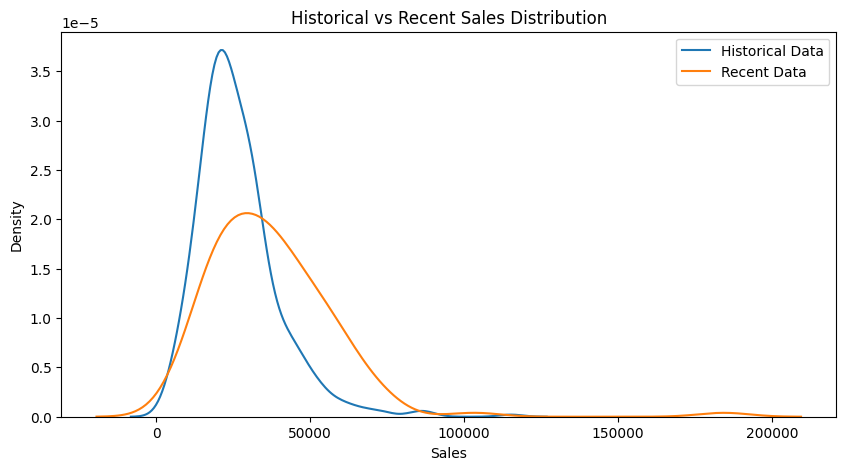

In [4]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    historical["Sales"],
    label="Historical Data"
)

sns.kdeplot(
    recent["Sales"],
    label="Recent Data"
)

plt.legend()

plt.title(
    "Historical vs Recent Sales Distribution"
)

plt.show()

In [5]:
from scipy.stats import ks_2samp

# Perform KS Test
ks_stat, p_value = ks_2samp(
    historical["Sales"],
    recent["Sales"]
)

print("KS Statistic:", round(ks_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Data Drift Detected")
else:
    print("No Significant Data Drift Detected")

KS Statistic: 0.326
P-value: 0.0
Data Drift Detected


# KS Statistical Test Interpretation

The Kolmogorov–Smirnov (KS) test compares the historical and recent sales distributions.

- **p-value < 0.05:** Significant statistical drift exists between the datasets.
- **p-value ≥ 0.05:** No significant drift is detected.

The KS test complements visual analysis by providing a quantitative measure of distribution change, enabling timely model monitoring and retraining decisions.

# Summary Statistics Comparison

In [6]:
comparison = pd.DataFrame({

    "Historical": historical["Sales"].describe(),

    "Recent": recent["Sales"].describe()

})

comparison

,Historical,Recent
count,483.000000,121.000000
mean,26573.643364,37518.467132
std,13351.004202,21795.149196
min,3439.670000,5701.870000
25%,18102.085000,22441.260000
50%,23934.460000,35206.920000
75%,31976.300000,48116.500000
max,115172.240000,184347.660000


# Drift Analysis

Distribution differences may indicate changing customer demand patterns.

Significant shifts in sales behavior could require model retraining.

# Business Insights

1. Customer purchasing behavior may evolve over time.

2. Changes in sales distribution can impact forecasting performance.

3. Monitoring drift helps maintain model reliability.

4. Early drift detection supports proactive model maintenance.

5. Drift analysis is an important component of MLOps workflows.

# Challenges Faced

Detecting drift requires continuous monitoring of incoming data.

Interpreting distribution changes requires both statistical and business understanding.

# Conclusion

Data drift detection was successfully performed by comparing historical and recent sales distributions.

Continuous monitoring of drift helps maintain forecasting accuracy and supports long-term model performance.